In [1]:
# Finds the distribution of waiting times
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

In [95]:
data_dir = '/home/kale-chen/Documents/PET/MDA_04112026/Data/run3_tcut_cwc.bin'
num_rows = os.path.getsize(data_dir) // 16
data = np.memmap(data_dir, dtype = np.int64, mode = 'r', shape = (num_rows, 2))
print(data[0:5])

[[ 472600926937023284  126945725190900338]
 [ 190279480864343363   77413568764971514]
 [ 579842158621886746 -312995548420313637]
 [ 478216755554026794  660913776549431204]
 [ 260369975660445441  765042746249840541]]


In [96]:
waiting_timesL = data[1:len(data), 0] - data[0:len(data) - 1, 0]
waiting_timesR = data[1:len(data), 1] - data[0:len(data) - 1, 1]
print(len(waiting_timesL), len(waiting_timesR))
print(np.min(waiting_timesL), np.min(waiting_timesR))
print(np.max(waiting_timesL), np.max(waiting_timesR))

694401 694401
-3651565539951118366 -3660620864243369370
3668743712095996475 3666487501665142992


In [77]:
bin_width = 10000000  # ps
max_waiting_time = 1e9 # ps
n_bins = int((max_waiting_time) / bin_width)
time_binsL = np.zeros(n_bins, dtype=np.int32)
time_binsR = np.zeros(n_bins, dtype=np.int32)
bin_indicesL = (waiting_timesL / bin_width).astype(int)
valid_maskL = (bin_indicesL >= 0) & (bin_indicesL < len(time_binsL))
np.add.at(time_binsL, bin_indicesL[valid_maskL], 1)
bin_indicesR = (waiting_timesR / bin_width).astype(int)
valid_maskR = (bin_indicesR >= 0) & (bin_indicesR < len(time_binsR))
np.add.at(time_binsR, bin_indicesR[valid_maskR], 1)

zero_countL = np.count_nonzero(waiting_timesL == 0)
print(zero_countL)
zero_countR = np.count_nonzero(waiting_timesR == 0)
print(zero_countR)

bins = np.arange(0, max_waiting_time, bin_width)
print(len(bins))

13086
13252
100


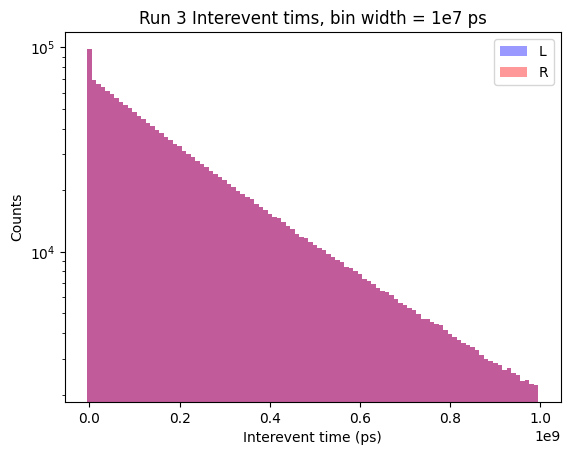

In [78]:
plt.bar(bins, time_binsL, width = bin_width, color = 'blue', alpha = 0.4, label = 'L')
plt.bar(bins, time_binsR, width = bin_width, color = 'red', alpha = 0.4, label = 'R')
#plt.xlim(-10000, 100000)
plt.yscale('log')
plt.xlabel('Interevent time (ps)')
plt.ylabel('Counts')
plt.title('Run 3 Interevent tims, bin width = 1e7 ps')
plt.legend()
plt.show()

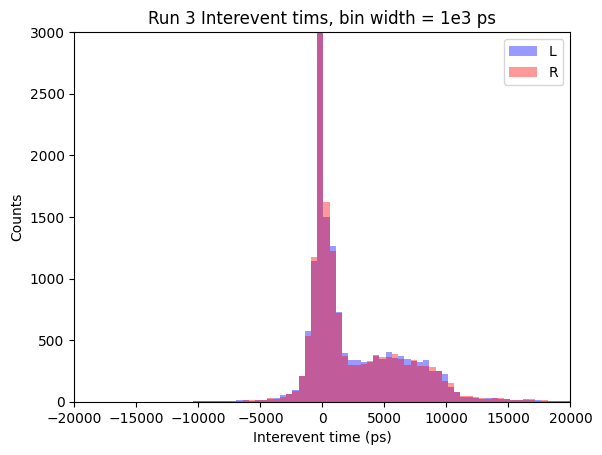

In [ ]:
bins = np.linspace(-20000, 100000, 240)

waiting_timesL_cut = waiting_timesL[waiting_timesL < 100000]
waiting_timesR_cut = waiting_timesR[waiting_timesR < 100000]
plt.hist(waiting_timesL_cut, bins = bins, color = 'blue', alpha = 0.4, label = 'L')
plt.hist(waiting_timesR_cut, bins = bins, color = 'red', alpha = 0.4, label = 'R')
plt.xlim(-20000, 20000)
plt.ylim(0, 3000)
#plt.yscale('log')
plt.xlabel('Interevent time (ps)')
plt.ylabel('Counts')
plt.title('Run 3 Interevent tims, bin width = 1e3 ps')
plt.legend()
plt.show()

In [87]:
# Search
import pandas as pd

path = '/home/kale-chen/Documents/PET/MDA_04112026/Data/run3.dat'
time_range = (585, 1150)

# If cutting on photopeak, need to specify:
photopeak_dir = os.path.join('/home/kale-chen/Documents/PET/MDA_04112026/Data/mcenter_ppbounds_a.txt')
photopeakL = np.genfromtxt(photopeak_dir, dtype = np.float32)[3072:] * 100
photopeakR = np.genfromtxt(photopeak_dir, dtype = np.float32)[:3072] * 100

same_times = []
time0 = -1
for chunk in tqdm(pd.read_csv(path, sep = '\t', chunksize = 10000000, usecols = [2, 3, 4, 7, 8, 9], header = None)):
    chunk.columns = ['TimeL', 'EnergyL', 'IDL', 'TimeR', 'EnergyR', 'IDR']
    chunk['IDL'] = (chunk['IDL'] - 131072) % 3072           # Convert IDs to 0-3071 range for ease of handling, convert back when writing tsv
    chunk['IDR'] = chunk['IDR'] % 3072                      
    chunk['EnergyL'] = chunk['EnergyL'] * 100               # Multiply Energy by 100 to allow for storage as int16 with 2 decimal precision
    chunk['EnergyR'] = chunk['EnergyR'] * 100
    if time0 == -1:
        time0 = chunk.iloc[0,0]
    chunk['TimeL'] = chunk['TimeL'] - time0
    chunk['TimeR'] = chunk['TimeR'] - time0
    energyL = chunk["EnergyL"].to_numpy(dtype=float)
    energyR = chunk["EnergyR"].to_numpy(dtype=float)
    lowerboundLs = photopeakL[chunk["IDL"], 0]
    upperboundLs = photopeakL[chunk["IDL"], 1]
    lowerboundRs = photopeakR[chunk["IDR"], 0]
    upperboundRs = photopeakR[chunk["IDR"], 1]
    mask = ((energyL > lowerboundLs)
        & (energyR > lowerboundRs))
    chunk = chunk[mask]
    chunk = chunk[(chunk['TimeL'] >= time_range[0] * 1e12) & (chunk['TimeL'] < time_range[1] * 1e12)]

    for i in range(len(chunk) - 1):
        if chunk['TimeL'].iloc[i] == chunk['TimeL'].iloc[i + 1]:
            same_times.append((chunk.iloc[i], chunk.iloc[i + 1]))
        if chunk['TimeR'].iloc[i] == chunk['TimeR'].iloc[i + 1]:
            same_times.append((chunk.iloc[i], chunk.iloc[i + 1]))

print(len(same_times))




19it [01:19,  4.18s/it]

26338


In [94]:
same_times[5]

(TimeL      5.850352e+14
 EnergyL    2.373409e+03
 IDL        1.928000e+03
 TimeR      5.850352e+14
 EnergyR    2.608198e+03
 IDR        2.604000e+03
 Name: 176843296, dtype: float64,
 TimeL      5.850352e+14
 EnergyL    2.373409e+03
 IDL        1.928000e+03
 TimeR      5.850352e+14
 EnergyR    2.244550e+03
 IDR        4.820000e+02
 Name: 176843297, dtype: float64)